# Spacecraft + CMG Dynamics Simulation

Reference: Oghim et al. (2025), *Deep reinforcement learning-based attitude control for spacecraft using control moment gyros*, ASR 75, 1129–1144.

---

## Equations of Motion

### 1. Quaternion kinematics (Eq. 1)
$$\dot{\mathbf{q}} = \frac{1}{2}\mathbf{q} \otimes \boldsymbol{\Omega}, \quad \boldsymbol{\Omega} = [0,\; \omega_x,\; \omega_y,\; \omega_z]^T$$

### 2. Euler rotational EOM (Eq. 6, 8)
$$J\dot{\boldsymbol{\omega}} + \dot{\mathbf{H}}_{cmg} + \boldsymbol{\omega}\times(J\boldsymbol{\omega} + \mathbf{H}_{cmg}) = \boldsymbol{\tau}_{ext}$$
$$\Rightarrow\quad J\dot{\boldsymbol{\omega}} = \boldsymbol{\tau} - \boldsymbol{\omega}\times J\boldsymbol{\omega}$$

where the CMG torque is (Eq. 7):
$$\boldsymbol{\tau} = -\dot{\mathbf{H}}_{cmg} - \boldsymbol{\omega}\times\mathbf{H}_{cmg} = -A(\boldsymbol{\delta})\dot{\boldsymbol{\delta}} - \boldsymbol{\omega}\times\mathbf{H}_{cmg}$$

### 3. CMG angular momentum — pyramid cluster (Eq. 9)
$$\mathbf{H}_{cmg} = h\begin{bmatrix} -\cos\beta\sin\delta_1 - \cos\delta_2 + \cos\beta\sin\delta_3 + \cos\delta_4 \\ \cos\delta_1 - \cos\beta\sin\delta_2 - \cos\delta_3 + \cos\beta\sin\delta_4 \\ \sin\beta(\sin\delta_1+\sin\delta_2+\sin\delta_3+\sin\delta_4) \end{bmatrix}$$

### 4. Jacobian $A(\boldsymbol{\delta})$ (Eq. 11)
$$A(\boldsymbol{\delta}) = h\begin{bmatrix} -\cos\beta\cos\delta_1 & \sin\delta_2 & \cos\beta\cos\delta_3 & -\sin\delta_4 \\ -\sin\delta_1 & -\cos\beta\cos\delta_2 & \sin\delta_3 & \cos\beta\cos\delta_4 \\ \sin\beta\cos\delta_1 & \sin\beta\cos\delta_2 & \sin\beta\cos\delta_3 & \sin\beta\cos\delta_4 \end{bmatrix}$$

### 5. Singularity measure
$$m = \det\!\left(\frac{A}{h}\cdot\frac{A^T}{h}\right) \quad (m\to 0\text{ at a singular configuration})$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from spacecraft_cmg import SpacecraftCMG

## Spacecraft & CMG Parameters (Table 2)

In [2]:
# ----------------------------------------------------------------
#  Spacecraft + CMG Parameters  (Oghim et al. 2025, Table 2)
# ----------------------------------------------------------------
DT = 0.1   # integration time step [s]

sc = SpacecraftCMG(
    J             = np.diag([21400.0, 20100.0, 5500.0]),  # inertia [kg·m²]
    h             = 1000.0,          # flywheel angular momentum [N·m·s]
    beta_deg      = 53.13,           # pyramid skew angle [deg]
    delta0_deg    = np.array([45., -45., 45., -45.]),  # initial gimbal angles [deg]
    delta_dot_max = 1.0,             # gimbal rate limit [rad/s]
    dt            = DT,
)

print('Inertia J [kg m^2]:', np.diag(sc.J))
print('Flywheel h [Nm s] :', sc.h)
print('Skew angle beta   :', np.rad2deg(sc.beta), 'deg')
print('Initial delta [deg]:', np.rad2deg(sc.delta0))
print('Initial H_cmg [Nm s]:', sc.H_cmg.round(6), '  <- should be [0,0,0]')
print('Initial SM          :', round(sc.singularity_measure, 4))

Inertia J [kg m^2]: [21400. 20100.  5500.]
Flywheel h [Nm s] : 1000.0
Skew angle beta   : 53.13 deg
Initial delta [deg]: [ 45. -45.  45. -45.]
Initial H_cmg [Nm s]: [-0.  0.  0.]   <- should be [0,0,0]
Initial SM          : 0.5243


## Open-loop Dynamics Simulation

Prescribed gimbal rate profiles $\dot{\boldsymbol{\delta}}(t)$ are applied without any feedback controller.  
This verifies that the dynamics model (quaternion norm, angular momentum conservation, etc.) behaves correctly.

In [3]:
# ----------------------------------------------------------------
#  Choose a gimbal rate profile
# ----------------------------------------------------------------
#
#  Profile A – constant positive rate on all 4 gimbals (pure z-torque)
#  Profile B – sinusoidal rates (wobble test)
#  Profile C – step then stop (spin-up & coast)
#
PROFILE = 'A'   # <-- change to 'B' or 'C' to explore

T_MAX = 30.0
STEPS = int(T_MAX / DT)
TIME  = np.linspace(0.0, T_MAX - DT, STEPS)

def gimbal_rate_cmd(t: float, delta: np.ndarray) -> np.ndarray:
    """Prescribed open-loop gimbal rate command at time t."""
    if PROFILE == 'A':
        # Constant 0.3 rad/s on all gimbals → net z-axis torque
        return np.array([0.3, 0.3, 0.3, 0.3])
    elif PROFILE == 'B':
        # Sinusoidal rates, different phases per gimbal
        return 0.5 * np.sin(np.array([1.0, 1.0, 1.0, 1.0]) * t
                            + np.array([0, np.pi/2, np.pi, 3*np.pi/2]))
    elif PROFILE == 'C':
        # Spin-up for 10 s, then stop
        rate = 0.5 if t < 10.0 else 0.0
        return np.array([rate, rate, rate, rate])
    return np.zeros(4)

In [4]:
# ----------------------------------------------------------------
#  Run simulation
# ----------------------------------------------------------------
sc.reset()   # q=[1,0,0,0], omega=[0,0,0], delta=delta0

log_q        = np.zeros((STEPS, 4))   # quaternion [qw, qx, qy, qz]
log_omega    = np.zeros((STEPS, 3))   # angular velocity [deg/s]
log_delta    = np.zeros((STEPS, 4))   # gimbal angles [deg]
log_ddot     = np.zeros((STEPS, 4))   # applied gimbal rates [rad/s]
log_H_cmg   = np.zeros((STEPS, 3))   # CMG angular momentum [N·m·s]
log_H_total  = np.zeros((STEPS, 3))   # total angular momentum [N·m·s]
log_tau      = np.zeros((STEPS, 3))   # CMG torque [N·m]
log_sm       = np.zeros(STEPS)        # singularity measure
log_qnorm    = np.zeros(STEPS)        # ||q|| (should stay = 1)

for i, t in enumerate(TIME):
    # log current state (before step)
    log_q[i]       = sc.q
    log_omega[i]   = np.rad2deg(sc.omega)
    log_delta[i]   = np.rad2deg(sc.delta)
    log_H_cmg[i]  = sc.H_cmg
    log_H_total[i] = sc.J @ sc.omega + sc.H_cmg   # total angular momentum
    log_sm[i]      = sc.singularity_measure
    log_qnorm[i]   = np.linalg.norm(sc.q)

    # command & step
    dd    = gimbal_rate_cmd(t, sc.delta)
    state = sc.step(dd)

    log_ddot[i] = np.clip(dd, -sc.delta_dot_max, sc.delta_dot_max)
    log_tau[i]  = state['tau']

print('Simulation done.')
print('  ||q|| drift  max:', np.abs(log_qnorm - 1.0).max())
print('  H_total drift  :', np.abs(log_H_total - log_H_total[0]).max().round(6),
      ' N m s  (0 = angular momentum conserved)')

Simulation done.
  ||q|| drift  max: 2.220446049250313e-16
  H_total drift  : 1e-06  N m s  (0 = angular momentum conserved)


## Results

<>:14: SyntaxWarning: invalid escape sequence '\|'
<>:14: SyntaxWarning: invalid escape sequence '\|'
C:\Users\User\AppData\Local\Temp\ipykernel_25800\1164896492.py:14: SyntaxWarning: invalid escape sequence '\|'
  axes[1].set_ylabel('$\|\mathbf{q}\|$  [-]')


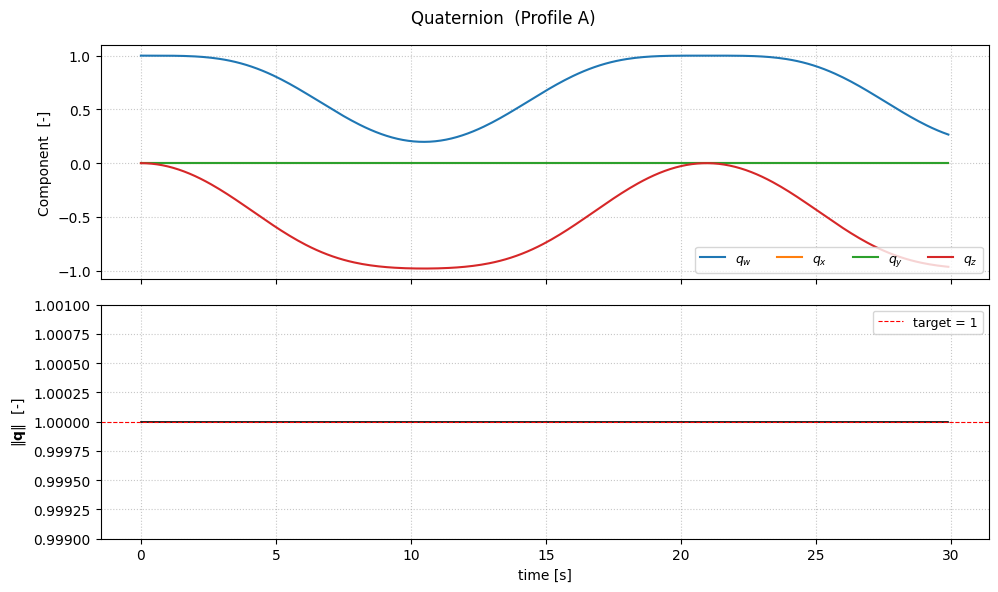

In [5]:
# ---- Plot 1: Quaternion components & norm ----------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle(f'Quaternion  (Profile {PROFILE})')

lbls_q = ['$q_w$', '$q_x$', '$q_y$', '$q_z$']
for j, lbl in enumerate(lbls_q):
    axes[0].plot(TIME, log_q[:, j], label=lbl)
axes[0].set_ylabel('Component  [-]')
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(True, ls=':', alpha=0.7)

axes[1].plot(TIME, log_qnorm, color='k', lw=1.2)
axes[1].axhline(1.0, color='r', ls='--', lw=0.8, label='target = 1')
axes[1].set_ylabel('$\|\mathbf{q}\|$  [-]')
axes[1].set_xlabel('time [s]')
axes[1].set_ylim(0.999, 1.001)
axes[1].legend(fontsize=9)
axes[1].grid(True, ls=':', alpha=0.7)

plt.tight_layout()
plt.show()

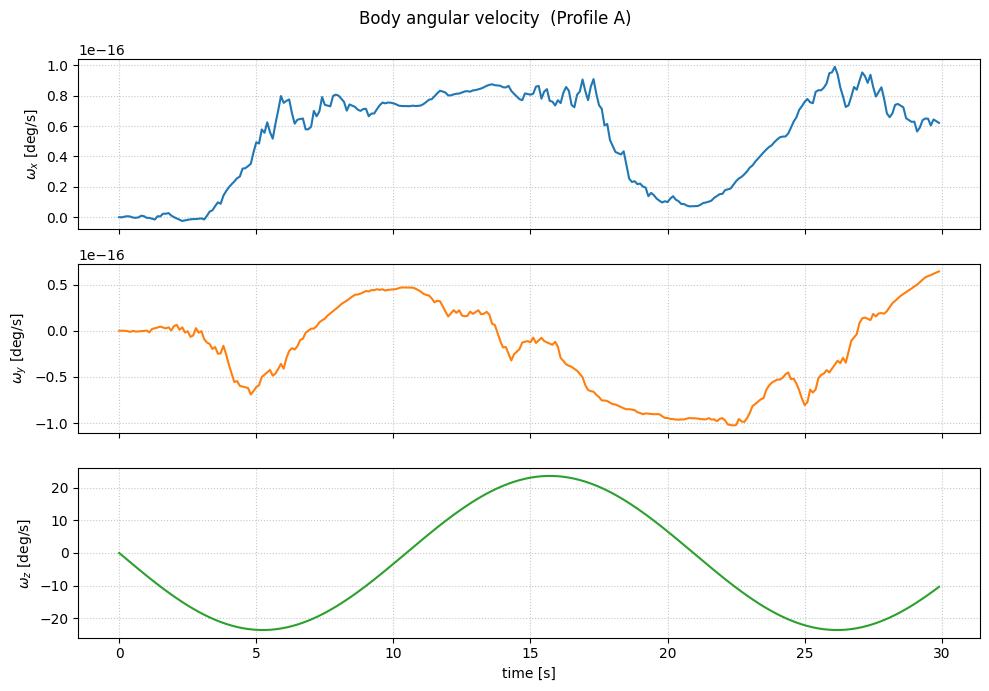

In [6]:
# ---- Plot 2: Angular velocity ----------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle(f'Body angular velocity  (Profile {PROFILE})')

for j, (ax, lbl) in enumerate(zip(axes, [r'$\omega_x$ [deg/s]', r'$\omega_y$ [deg/s]', r'$\omega_z$ [deg/s]'])):
    ax.plot(TIME, log_omega[:, j], color=f'C{j}')
    ax.set_ylabel(lbl, fontsize=10)
    ax.grid(True, ls=':', alpha=0.7)
axes[-1].set_xlabel('time [s]')

plt.tight_layout()
plt.show()

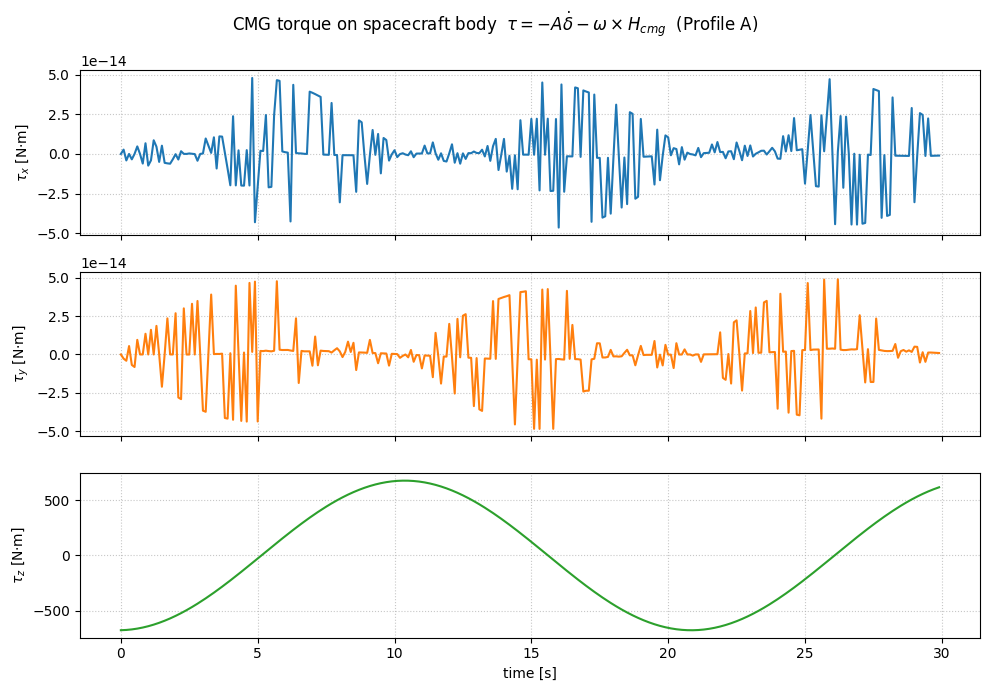

In [7]:
# ---- Plot 3: CMG torque on spacecraft body ---------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.suptitle(f'CMG torque on spacecraft body  $\\tau = -A\\dot{{\\delta}} - \\omega\\times H_{{cmg}}$  (Profile {PROFILE})')

for j, (ax, lbl) in enumerate(zip(axes, [r'$\tau_x$ [N·m]', r'$\tau_y$ [N·m]', r'$\tau_z$ [N·m]'])):
    ax.plot(TIME, log_tau[:, j], color=f'C{j}')
    ax.set_ylabel(lbl, fontsize=10)
    ax.grid(True, ls=':', alpha=0.7)
axes[-1].set_xlabel('time [s]')

plt.tight_layout()
plt.show()

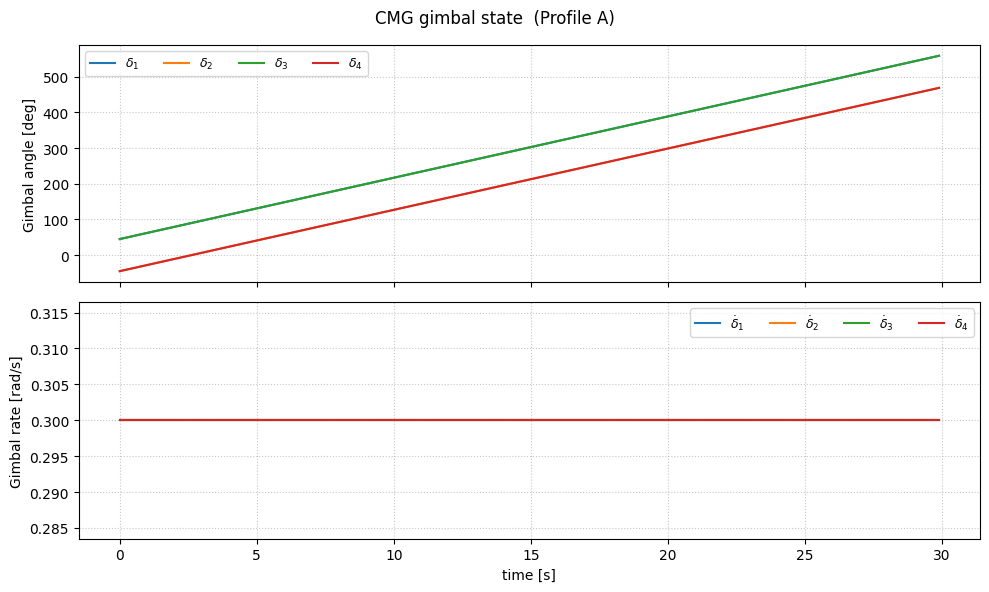

In [8]:
# ---- Plot 4: Gimbal angles & rates -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle(f'CMG gimbal state  (Profile {PROFILE})')

for j in range(4):
    axes[0].plot(TIME, log_delta[:, j], label=f'$\\delta_{j+1}$')
axes[0].set_ylabel('Gimbal angle [deg]')
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(True, ls=':', alpha=0.7)

for j in range(4):
    axes[1].plot(TIME, log_ddot[:, j], label=f'$\\dot{{\\delta}}_{j+1}$')
axes[1].set_ylabel('Gimbal rate [rad/s]')
axes[1].set_xlabel('time [s]')
axes[1].legend(ncol=4, fontsize=9)
axes[1].grid(True, ls=':', alpha=0.7)

plt.tight_layout()
plt.show()

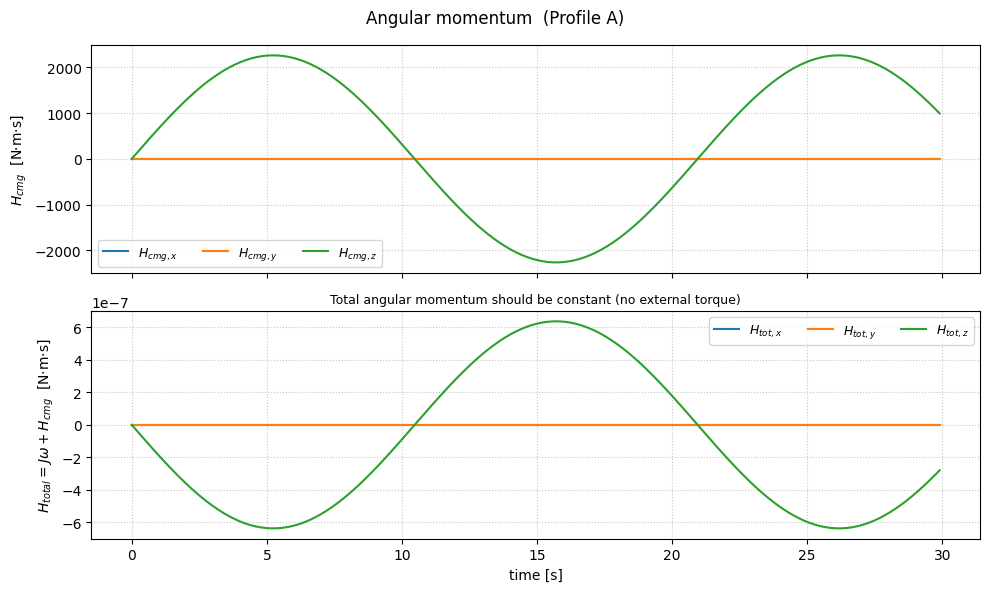

In [9]:
# ---- Plot 5: Angular momentum ----------------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
fig.suptitle(f'Angular momentum  (Profile {PROFILE})')

lbls = ['x', 'y', 'z']
for j in range(3):
    axes[0].plot(TIME, log_H_cmg[:, j], label=f'$H_{{cmg,{lbls[j]}}}$')
axes[0].set_ylabel('$H_{cmg}$  [N·m·s]')
axes[0].legend(ncol=3, fontsize=9)
axes[0].grid(True, ls=':', alpha=0.7)

for j in range(3):
    axes[1].plot(TIME, log_H_total[:, j], label=f'$H_{{tot,{lbls[j]}}}$')
axes[1].set_ylabel('$H_{total} = J\\omega + H_{cmg}$  [N·m·s]')
axes[1].set_xlabel('time [s]')
axes[1].legend(ncol=3, fontsize=9)
axes[1].grid(True, ls=':', alpha=0.7)
axes[1].set_title('Total angular momentum should be constant (no external torque)', fontsize=9)

plt.tight_layout()
plt.show()

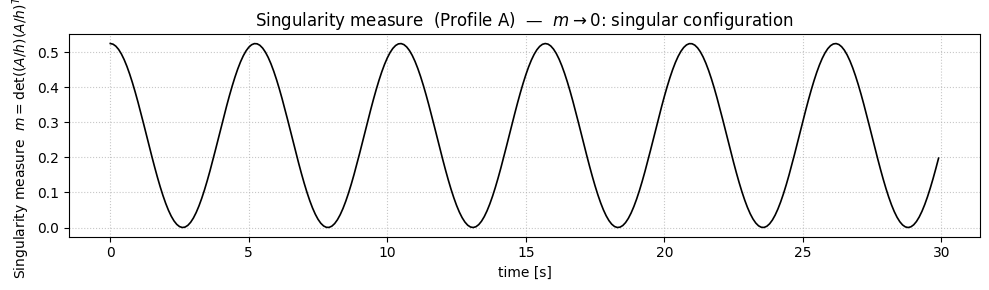

In [10]:
# ---- Plot 6: Singularity measure -------------------------------
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(TIME, log_sm, color='k', lw=1.2)
ax.set_ylabel('Singularity measure  $m = \\det((A/h)(A/h)^T)$')
ax.set_xlabel('time [s]')
ax.set_title(f'Singularity measure  (Profile {PROFILE})  —  $m\\to 0$: singular configuration')
ax.grid(True, ls=':', alpha=0.7)
plt.tight_layout()
plt.show()